# K-Means Clustering

**Giới thiệu**

Một trong những thuật toán cơ bản nhất trong Unsupervised Learning. <br>
**Mục đích**: phân dữ liệu thành các cụm (cluster) khác nhau sao cho dữ liệu trong cùng một cụm có tính chất giống nhau. <br>
**Ý tưởng**: tập hợp các điểm gần nhau trong một không gian nào đó (có thể nhiều chiều nếu thông tin về 1 điểm dữ liệu rất lớn).
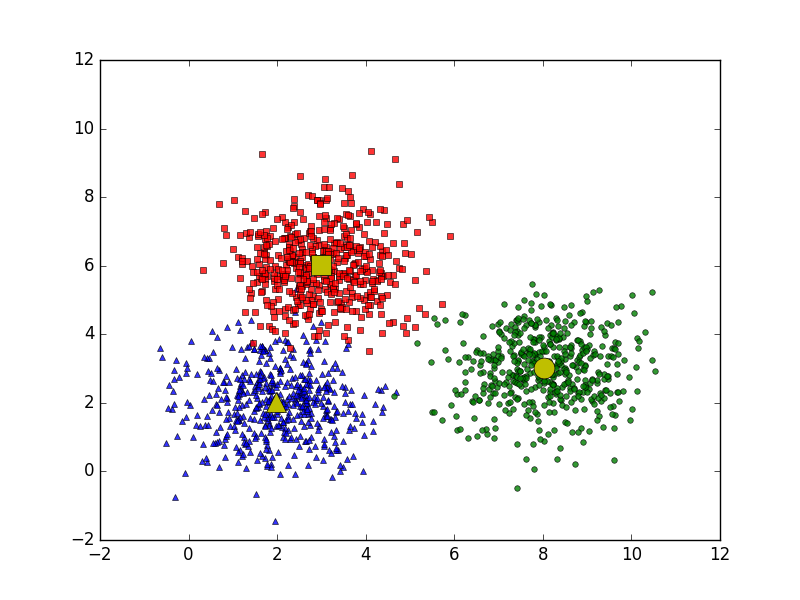


**Bài toán**: Giả sử mỗi cluster có 1 điểm đại diện (center) màu vàng. Những điểm xung quanh mỗi center thuộc vào cùng nhóm với center đó. Xác định **ranh giới** giữa các clusters <br>
**Ví dụ: Voronoi Diagram** <br>
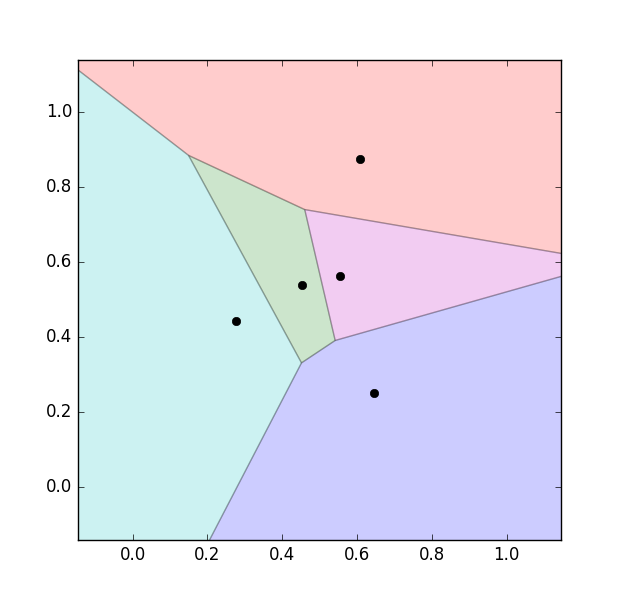

**Phân tích toán học**

Mục đích cuối cùng của thuật toán phân nhóm này là: từ dữ liệu đầu vào và số lượng nhóm chúng ta muốn tìm, hãy chỉ ra center của mỗi nhóm và phân các điểm dữ liệu vào các nhóm tương ứng. Giả sử thêm rằng mỗi điểm dữ liệu chỉ thuộc vào đúng một nhóm.

**Tóm tắt thuật toán**

**Đầu vào**: Dữ liệu X và số lượng cluster cần tìm K. <br>
**Đầu ra**: Các center M và label vector cho từng điểm dữ liệu Y. <br>
Chọn K

1.   Chọn K điểm bất kỳ làm các center ban đầu.
2.   Phân mỗi điểm dữ liệu vào cluster có center gần nó nhất.
3.   Nếu việc gán dữ liệu vào từng cluster ở bước 2 không thay đổi so với vòng lặp trước nó thì ta dừng thuật toán.
4.  Cập nhật center cho từng cluster bằng cách lấy trung bình cộng của tất các các điểm dữ liệu đã được gán vào cluster đó sau bước 2.
5.  Quay lại bước 2. <br>
Chúng ta có thể đảm bảo rằng thuật toán sẽ dừng lại sau một hữu hạn vòng lặp. Hàm mất mát trả về 1 giá trị dương sau bước 2 hoặc 3 nhưng giá trị của hàm mất mát lại giảm đi. Do nếu một dãy giảm và bị chặn dưới thì nó sẽ hội tụ và số lượng cách phân nhóm là hữu hạn nên đến một lúc nào đó, giá trị của hàm sẽ không đổi nữa, chúng ta có thể dừng thuât toán tại đây



**Ví dụ**

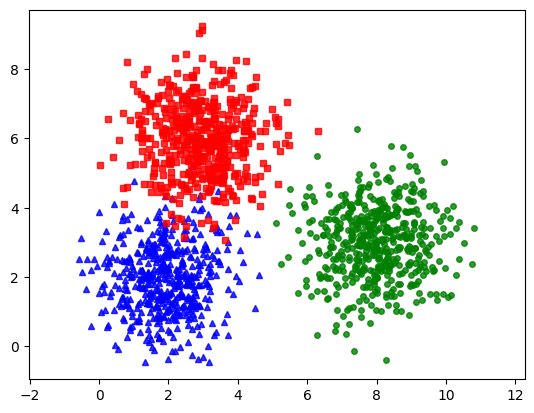

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(23) #fixed random np_array

means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]] #ma trận đơn vị
N = 500
X0 = np.random.multivariate_normal(means[0], cov, N) #dữ liệu phân phối chuẩn theo nhiều chiều
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis = 0)
K = 3

original_label = np.asarray([0]*N + [1]*N + [2]*N).T

def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]

    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)

    plt.axis('equal')
    plt.show()

kmeans_display(X, original_label)

Có thể thấy một vài điểm đỏ lấn sang điểm xanh

**K-means clustering algorithm**

In [8]:
#test
print(X.shape[1])
print(X.shape[0])
print(np.random.choice(X.shape[0],3,replace=False))
print(X[np.random.choice(X.shape[0],3,replace=False)])

2
1500
[1438  796  602]
[[7.55623376 3.08530847]
 [1.22238059 2.94863382]
 [8.07110293 2.67832028]]


([array([[8.04849445, 2.25621513],
       [9.00433912, 1.80239825],
       [2.6041478 , 6.71939801]]), array([[7.08107132, 2.84908541],
       [9.34272773, 2.40401679],
       [2.377985  , 4.15542934]]), array([[7.32804958, 3.08945913],
       [9.01732839, 2.88762435],
       [2.39625372, 3.95998631]]), array([[7.25069992, 3.05934252],
       [8.94852874, 2.9651709 ],
       [2.39327263, 3.95806476]]), array([[7.19868371, 3.0203026 ],
       [8.90708519, 3.03349459],
       [2.39041885, 3.95638657]]), array([[7.16604922, 2.98294096],
       [8.87225203, 3.07807989],
       [2.39041885, 3.95638657]]), array([[7.14741171, 2.96127512],
       [8.85035452, 3.10063189],
       [2.39041885, 3.95638657]]), array([[7.13298415, 2.9339219 ],
       [8.83100781, 3.12804486],
       [2.39041885, 3.95638657]]), array([[7.13127318, 2.91238788],
       [8.81979745, 3.13784884],
       [2.39327263, 3.95806476]]), array([[7.12293616, 2.89994398],
       [8.80806487, 3.14820929],
       [2.39327263, 3.9

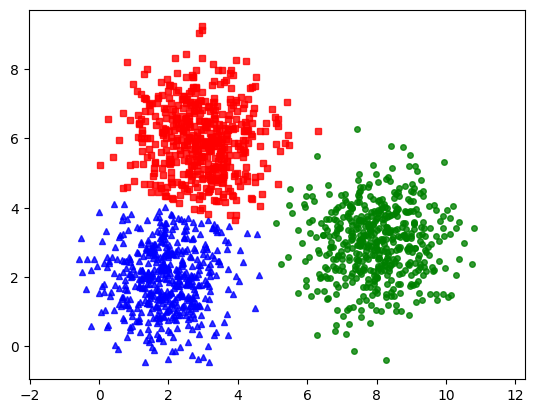

In [30]:
from scipy.spatial.distance import cdist #lib for counting distance
def kmeans_init_centers(X, k):
    # randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace=False)]

def kmeans_assign_labels(X, centers):
    # calculate pairwise distances between data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
        # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

def has_converged(centers, new_centers):
    # return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) ==
        set([tuple(a) for a in new_centers]))     #array->tuple->set

def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]  #ma trận tâm
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

print(kmeans(X,K))

(centers, labels, it) = kmeans(X, K)
print('Centers found by our algorithm:')
print(centers[-1])

kmeans_display(X, labels[-1])

**Dùng thư viện Skikit-learn**

Centers found by scikit-learn:
[[7.9813967  2.99960582]
 [1.902247   1.95045864]
 [2.92450659 5.97383842]]


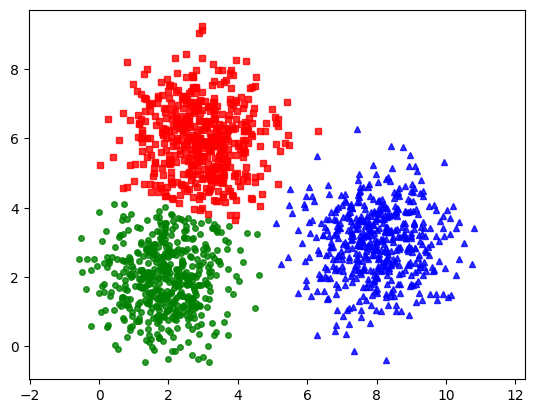

In [33]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
print('Centers found by scikit-learn:')
print(kmeans.cluster_centers_)
pre_label = kmeans.predict(X)
kmeans_display(X, pre_label)


**Hạn chế:**


*   Chúng ta cần biết trước số lượng cluster cần clustering
*   Nghiệm cuối cùng phụ thuộc vào centers được init ban đầu. Có thể hội tụ chậm hoặc có thể không chính xác (local minimum) - có thể khắc phục bằng kmeans++ hoặc random nhiều lần.
*   Các cluster cần có số điểm gần bằng nhau
*   Các cluster cần có dạng gần hình tròn
*   Một cluster nằm trong một cluster khác (VD: smile face)
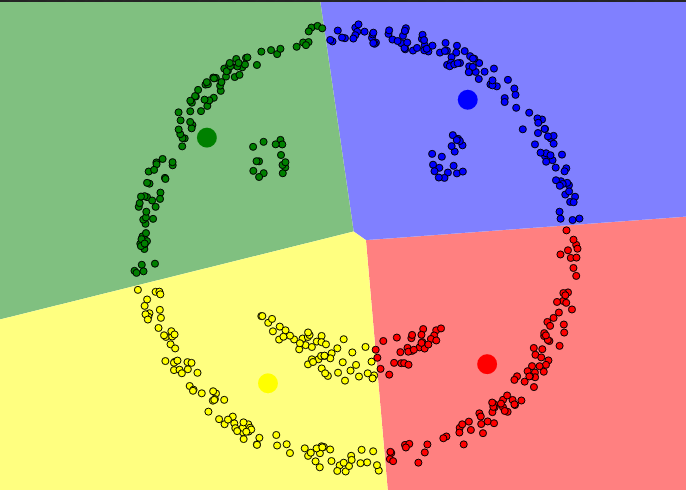
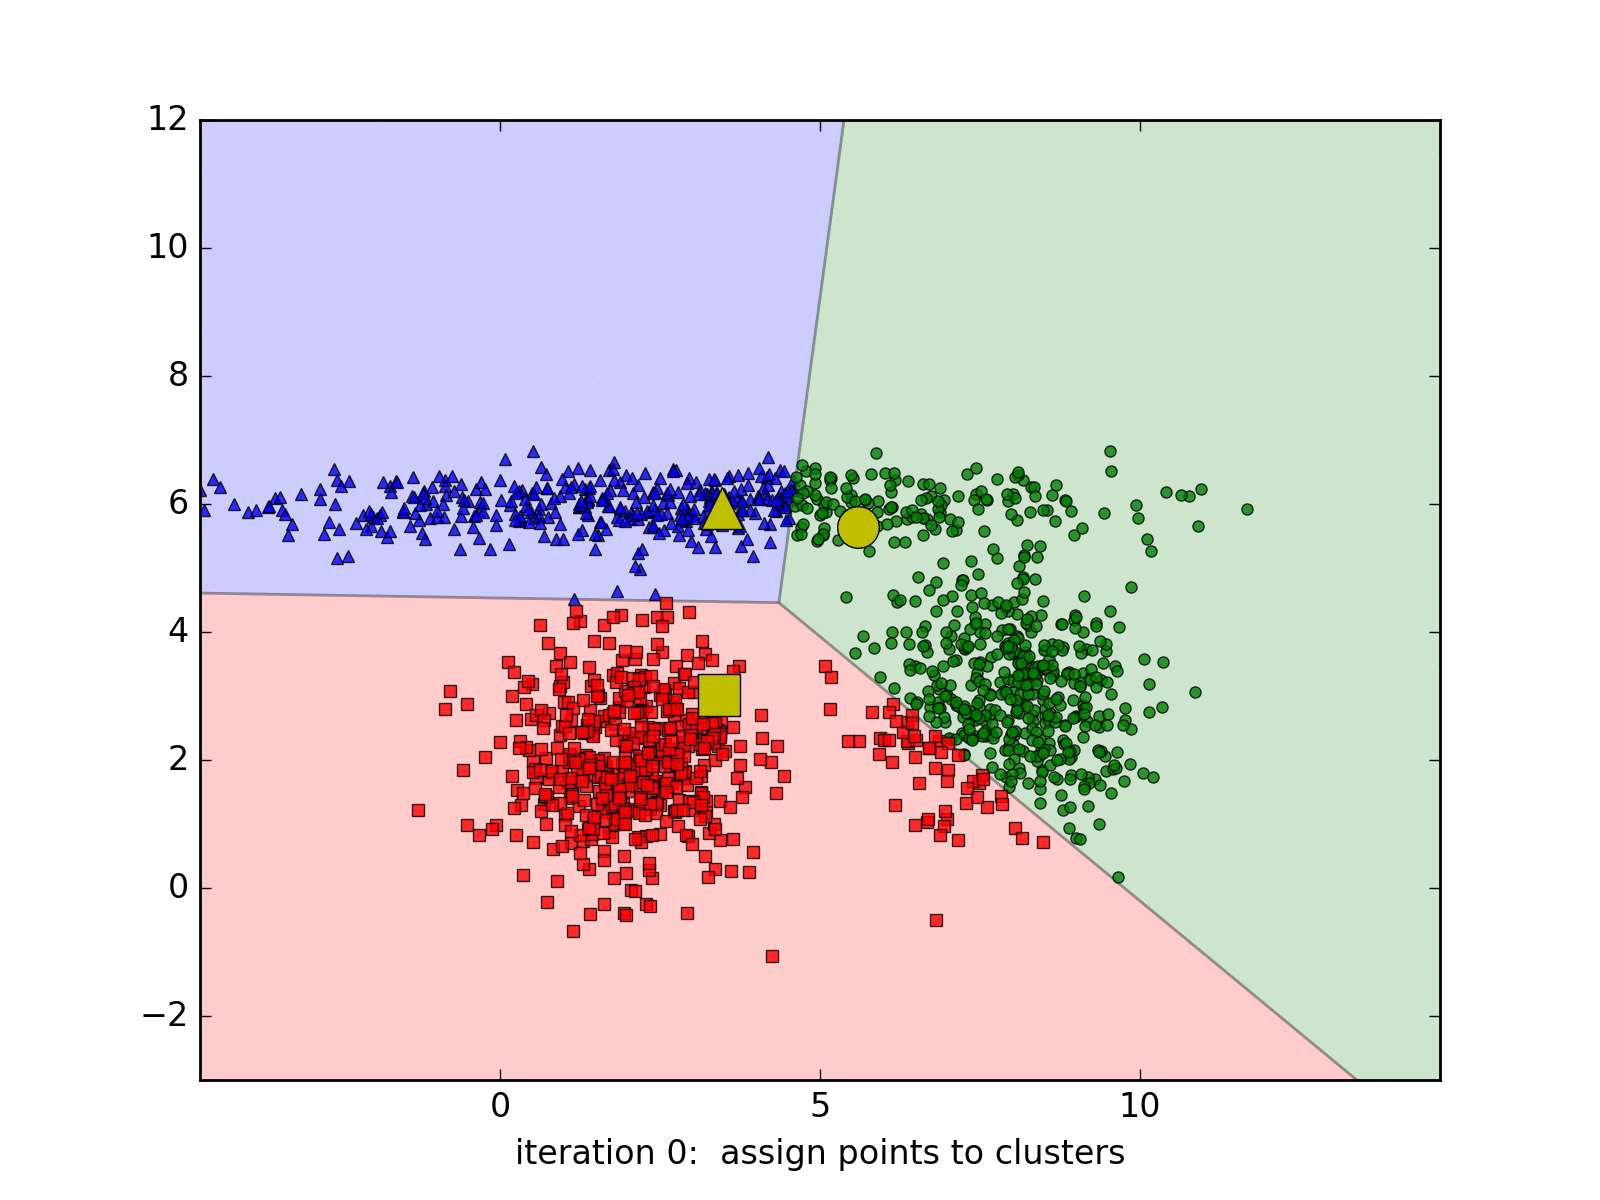

